`conda activate imgpro`

In [186]:
import utils
import numpy as np
import os
import glob
import h5py
import matplotlib.pyplot as plt
from scipy import signal
utils.default_plt_params()

In [2]:
data_pth = r'C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf415_no_id' # these are data with both off and on food time points, but without neuron ID labels

# data_pth = r'C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf702_with_id' # these are data with only on-food time points, but with neuron ID labels

nsm_idx = 74 # was 75 in candy's julia notebook, which is 1 based, but in python we start counting from 0, so we need to subtract 1

uid = '2022-04-12-02-data.h5'

path_h5 = os.path.join(data_pth,uid)

# run this cell if this is a SWF415 dataset (without neuron ID labels, both off-food and on-food time points were recorded)

with h5py.File(path_h5, 'r') as h5f:
    data = utils.h5_to_dict(h5f)
     


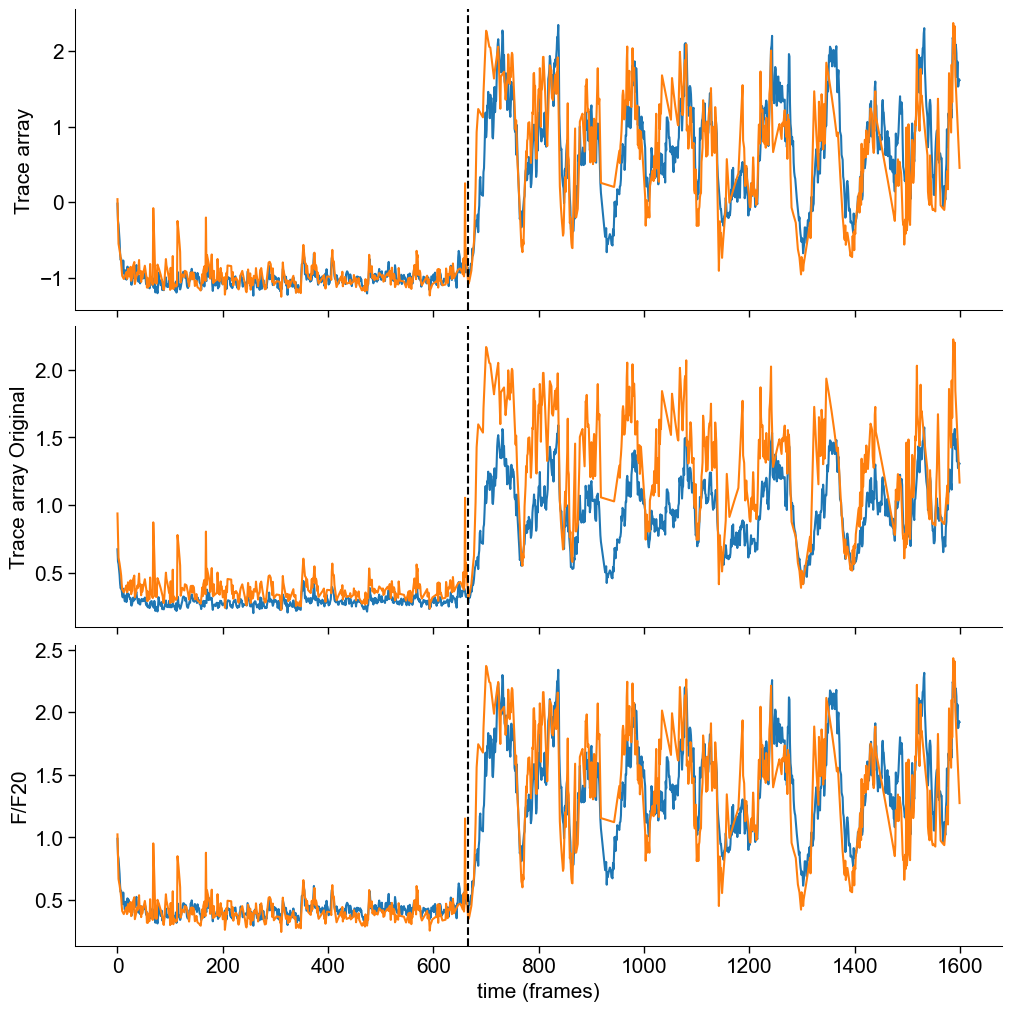

In [3]:
# plot the NSM traces

trace2plot = 'trace_array' # 'trace_array', 'trace_array_original', 'traces_array_F_F20'

fig, axes, nt = utils.pretty_subplots(nrows=3, ncols=1, figsize=(10,10), sharex=True)

nsm_idx = data['gcamp']['idx_nsm']

axs = []
axs.append(nt())
axs.append(nt())
axs.append(nt())

if len(nsm_idx) > 1:
    for i in range(len(nsm_idx)):
        axs[0].plot(data['gcamp']['trace_array'][:,nsm_idx[i]-1], label=f'NSM {i+1}')
        axs[1].plot(data['gcamp']['trace_array_original'][:,nsm_idx[i]-1], label=f'NSM {i+1}')
        axs[2].plot(data['gcamp']['traces_array_F_F20'][:,nsm_idx[i]-1], label=f'NSM {i+1}')
else:    
    axs[0].plot(data['gcamp']['trace_array'][:,nsm_idx-1], label='NSM')
    axs[1].plot(data['gcamp']['trace_array_original'][:,nsm_idx-1], label='NSM')
    axs[2].plot(data['gcamp']['traces_array_F_F20'][:,nsm_idx-1], label='NSM')

axs[0].axvline(data['timing']['time_food_encounter'], color='black', linestyle='--')
axs[1].axvline(data['timing']['time_food_encounter'], color='black', linestyle='--')
axs[2].axvline(data['timing']['time_food_encounter'], color='black', linestyle='--')
axs[0].set_ylabel('Trace array')
axs[1].set_ylabel('Trace array Original')
axs[2].set_ylabel('F/F20')

plt.xlabel('time (frames)')

plt.show()

# wavelet analysis for time-frequency

In [91]:

def morlet_wavelet(t, f, sigma):
    '''
    Complex Morlet wavelet composed of a Gaussian envelope and a plane wave.

        ψ(t, f) = (σ√π)^{-1/2} · exp(-t² / (2σ²)) · exp(2πift)

    The normalization (σ√π)^{-1/2} ensures unit L2 norm so that wavelet
    coefficients can be compared across frequency ranges.

    Parameters
    ----------
    t : array_like
        Time array (seconds).
    f : float
        Center frequency of the wavelet (Hz).
    sigma : float
        Width of the Gaussian envelope (seconds).

    Returns
    -------
    psi : ndarray (complex)
        Morlet wavelet evaluated at times t.
    '''
    normalization = (sigma * np.sqrt(np.pi)) ** (-0.5)
    gaussian = np.exp(-t**2 / (2 * sigma**2))
    plane_wave = np.exp(2j * np.pi * f * t)
    return normalization * gaussian * plane_wave


def get_gaussian_sigma(f, ksi=4):
    '''
    Width of the Gaussian envelope of the Morlet wavelet.

        σ = ξ / (2πf)

    Higher frequency wavelets have narrower envelopes; lower frequency
    wavelets have wider ones.

    Default ξ = 4 (Katz et al., Nature Comms 2019): enables detection of
    local frequency variations on scales larger than two periods while
    enabling robust estimation of the local frequency itself.

    Parameters
    ----------
    f : float or array_like
        Frequency (Hz).
    ksi : float, optional
        Wavelet parameter (default: 4).

    Returns
    -------
    sigma : float or ndarray
        Gaussian envelope width (seconds).
    '''
    return ksi / (2 * np.pi * f)


def morlet_wavelet_ft(f, f0, sigma):
    '''
    Analytical Fourier transform of the Morlet wavelet.

        Ψ̂(f) = (σ√π)^{-1/2} · σ√(2π) · exp(-2π²σ²(f - f₀)²)

    Used internally by wavelet_spectrum() to compute the transform
    efficiently in the frequency domain.

    Parameters
    ----------
    f : array_like
        Frequency values at which to evaluate the FT (Hz).
    f0 : float
        Center frequency of the Morlet wavelet (Hz).
    sigma : float
        Gaussian envelope width (seconds).

    Returns
    -------
    psi_hat : ndarray (real)
        Fourier transform of the Morlet wavelet.
    '''
    norm = (sigma * np.sqrt(np.pi)) ** (-0.5)
    return norm * sigma * np.sqrt(2 * np.pi) * np.exp(
        -2 * np.pi**2 * sigma**2 * (f - f0)**2
    )


def pad_reflect(signal):
    '''
    Pad a 1-D signal with reflected copies on both ends.

    Reflections do not repeat the endpoint values, producing a smooth
    continuation that minimises edge effects in wavelet transforms.

    Parameters
    ----------
    signal : ndarray, shape (n,)
        Input signal.

    Returns
    -------
    padded : ndarray, shape (3n - 2,)
        Reflected-padded signal.
    n_pad : int
        Number of samples added on the left.
    '''
    left_pad = signal[::-1][:-1]   # reverse, drop duplicate endpoint
    right_pad = signal[::-1][1:]   # reverse, drop duplicate endpoint
    padded = np.concatenate([left_pad, signal, right_pad])
    return padded, len(left_pad)


def wavelet_spectrum(signal, freqs, dt, ksi=4):
    '''
    Wavelet spectrum W(t, f) of a signal using complex Morlet wavelets.

        W(t, f) = ∫ S(t') ψ(t - t', f) dt'

    computed in the frequency domain as  IFFT[ FFT(S) · Ψ̂(f) ].

    Edge effects are minimised by padding the signal with reflected copies
    on both ends before transforming, then extracting the original time range.

    Parameters
    ----------
    signal : ndarray, shape (n_timepoints,) or (n_timepoints,1)
        Input time series.
    freqs : ndarray
        Frequencies to analyse (Hz).  Paper uses 0.01–0.2 Hz.
    dt : float
        Sampling interval (seconds per frame).
    ksi : float, optional
        Wavelet parameter (default: 4).

    Returns
    -------
    W : ndarray, shape (n_timepoints, n_frequencies), complex
        Complex wavelet coefficients.  |W| gives amplitude.
    '''
    if signal.ndim == 2 and signal.shape[1] == 1:
        signal = signal[:, 0]
    n_orig = len(signal)

    # Pad with reflections
    padded, n_pad = pad_reflect(signal)
    n_padded = len(padded)

    # FFT of the padded signal (computed once)
    S_fft = np.fft.fft(padded)

    # Frequency axis that matches the FFT bins
    freqs_fft = np.fft.fftfreq(n_padded, d=dt)

    W = np.zeros((n_orig, len(freqs)), dtype=complex)

    for i, f0 in enumerate(freqs):
        sigma = get_gaussian_sigma(f0, ksi)

        # Analytical FT of the Morlet wavelet at the FFT frequencies
        Psi_hat = morlet_wavelet_ft(freqs_fft, f0, sigma)

        # Convolution in frequency domain, then back to time domain
        W_full = np.fft.ifft(S_fft * Psi_hat)

        # Keep only the segment corresponding to the original signal
        W[:, i] = W_full[n_pad:n_pad + n_orig]

    return W


def time_averaged_spectrum(W, start_idx=None, end_idx=None):
    '''
    Time-average the wavelet amplitude spectrum |W(t, f)|.

    Averages the absolute value of wavelet coefficients over a time window,
    e.g. from the onset of spontaneous activity to the end of the recording.

    Parameters
    ----------
    W : ndarray, shape (n_timepoints, n_frequencies), complex
        Wavelet spectrum from wavelet_spectrum().
    start_idx : int or None
        First time index to include (default: beginning).
    end_idx : int or None
        Last time index (exclusive) to include (default: end).

    Returns
    -------
    spectrum : ndarray, shape (n_frequencies,)
        Time-averaged amplitude spectrum.
    '''
    return np.mean(np.abs(W[start_idx:end_idx, :]), axis=0)
    # return np.mean(np.abs(W), axis=0)


def weighted_average_spectra(spectra, weights):
    '''
    Weighted average of time-averaged wavelet spectra across animals.

    Each animal's spectrum is weighted by the fraction of time it was
    spontaneously active during the recording period.

    Parameters
    ----------
    spectra : list of ndarray or ndarray, shape (n_animals, n_frequencies)
        Time-averaged spectra for each animal.
    weights : array_like, shape (n_animals,)
        Weight per animal (e.g. fraction of recording that is
        spontaneously active).

    Returns
    -------
    mean_spectrum : ndarray, shape (n_frequencies,)
        Weighted mean spectrum across animals.
    '''
    spectra = np.array(spectra)
    weights = np.array(weights, dtype=float)
    weights = weights / weights.sum()          # normalise to sum to 1
    return np.average(spectra, axis=0, weights=weights)


def minmax_normalize(trace):
    '''
    Min-max normalise a trace so its minimum equals 0 and maximum equals 1.

        normalised = (trace - min) / (max - min)

    Used for heatmap plots of spontaneous glutamate and calcium activities.

    Parameters
    ----------
    trace : ndarray
        Raw fluorescence trace.

    Returns
    -------
    normalised : ndarray
        Trace scaled to [0, 1].
    '''
    mn = np.min(trace)
    mx = np.max(trace)
    if mx == mn:
        return np.zeros_like(trace, dtype=float)
    return (trace - mn) / (mx - mn)


In [17]:
time_axis[-1]

np.float64(940.5882352941177)

  neuron 1/1


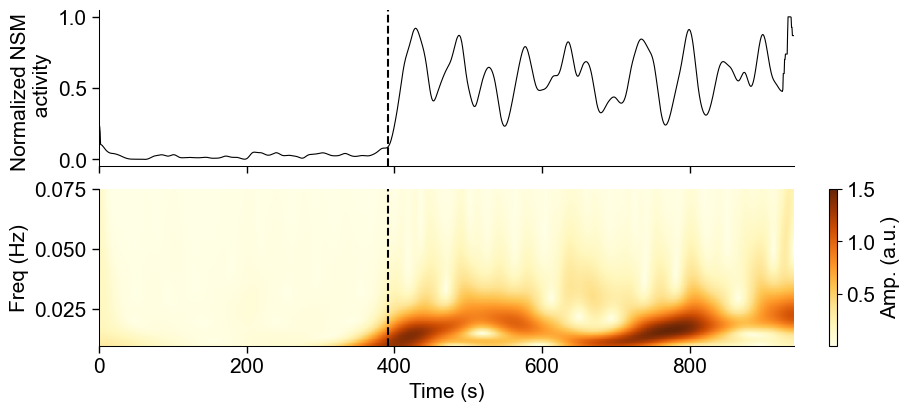

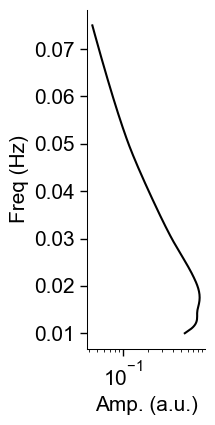

In [ ]:

# --- Example usage: compute and plot wavelet spectrum for NSM trace ---

# Choose which trace to analyze
trace_key = 'trace_array'   # F/F20 trace
nsm_idx = data['gcamp']['idx_nsm']

# Handle single vs multiple NSM indices
if hasattr(nsm_idx, '__len__') and len(nsm_idx) > 1:
    nsm_trace = data['gcamp'][trace_key][:, nsm_idx[0] - 1]
else:
    nsm_trace = data['gcamp'][trace_key][:, int(nsm_idx) - 1]

# normalize nsm_trace b/w 0 and 1
nsm_trace = minmax_normalize(nsm_trace)

# gstv denoise nsm_trace
nsm_trace, _ = smooth_neural_data_gstv(nsm_trace.reshape(1, -1).T)

# Sampling interval (seconds per frame) — adjust if your data has a different frame rate
# volume_rate = data['timing'].get('volume_rate', 1.0)  # volumes per second
volume_rate = 1.7
if isinstance(volume_rate, np.ndarray):
    volume_rate = volume_rate.item()
dt = 1.0 / volume_rate  # seconds per frame

# Frequencies to analyse (paper: 0.01 – 0.2 Hz)
freqs = np.linspace(0.01, 0.075, 200)

# Compute wavelet spectrum
W = wavelet_spectrum(nsm_trace, freqs, dt, ksi=3.5)

# ---- Plot the wavelet amplitude spectrogram ----
fig, axes, nt = utils.pretty_subplots(nrows=2, ncols=1, figsize=(9, 4), sharex=True)

time_axis = np.arange(len(nsm_trace)) * dt  # seconds

ax0 = nt()
ax0.plot(time_axis, nsm_trace, 'k', linewidth=0.8)
ax0.axvline(data['timing']['time_food_encounter'] * dt, color='black', ls='--', label='food encounter')
ax0.set_ylabel('Normalized NSM \n activity')
# ax0.legend(loc='upper right')

ax1 = nt()
im = ax1.pcolormesh(time_axis, freqs, np.abs(W).T, shading='auto', cmap='YlOrBr')
ax1.axvline(data['timing']['time_food_encounter'] * dt, color='black', ls='--')
ax1.set_ylabel('Freq (Hz)')
ax1.set_xlabel('Time (s)')
fig.colorbar(im, ax=ax1, label='Amp. (a.u.)')
# plt.tight_layout()
plt.show()


# --- Time-averaged wavelet spectrum ---

# Average from onset of spontaneous activity (food encounter) to end of recording
food_idx = int(data['timing']['time_food_encounter'])
avg_spectrum = time_averaged_spectrum(W, start_idx=food_idx, end_idx=None)

# plot the time-averaged spectrum on logx scale
fig, ax = utils.pretty_plot(figsize=(2.4, 4.5))
ax.plot(avg_spectrum, freqs, 'k', linewidth=1.5)
ax.set_xscale('log')
ax.set_xlabel('Amp. (a.u.)')
ax.set_ylabel('Freq (Hz)')
# ax.set_title('Time-averaged wavelet spectrum')
plt.tight_layout()
plt.show()



# Signal smoothing and normalization


In [206]:
from scipy.linalg import solve_banded
from scipy.ndimage import gaussian_filter1d


# ---------------------------------------------------------------------------
#  Group Sparse Total Variation (GSTV) denoising
# ---------------------------------------------------------------------------

def gstv(y, k, lam, n_outer=15, n_inner=30, rho=1.0, eps=1e-10, tol=1e-6):
    '''
    Group Sparse Total Variation (GSTV) denoising.

    Solves:  argmin_x  1/2 ||y - x||² + λ Σ_i ||d_{i:i+k}||₂

    where d = diff(x) are first-order differences and the ℓ₂ norms are
    taken over overlapping groups of k consecutive differences.

    Uses the Majorization–Minimization (MM) algorithm
    (Selesnick & Chen, IEEE Sig. Proc. Lett. 2013) with an ADMM inner
    solver for each weighted 1-D TV sub-problem.

    Parameters
    ----------
    y       : 1-D array — noisy input signal (length n).
    k       : int       — group / window size for overlapping differences.
    lam     : float     — regularization strength (λ).
    n_outer : int       — MM iterations (default 15).
    n_inner : int       — ADMM iterations per MM step (default 30).
    rho     : float     — ADMM penalty parameter (default 1.0).
    eps     : float     — smoothing constant for group norms (default 1e-10).
    tol     : float     — convergence tolerance (default 1e-6).

    Returns
    -------
    x : 1-D array — denoised signal (length n).
    '''
    y = np.asarray(y, dtype=float)
    n = len(y)
    x = y.copy()
    nd = n - 1                       # number of first differences

    # Pre-build the band matrix for  (I + ρ D^T D)  — constant across iters
    ab = np.empty((3, n))
    ab[0, 0]  = 0.0
    ab[0, 1:] = -rho                 # super-diagonal
    ab[1, :]  = 1.0 + 2.0 * rho     # main diagonal
    ab[1, 0]  = 1.0 + rho
    ab[1, -1] = 1.0 + rho
    ab[2, :-1] = -rho                # sub-diagonal
    ab[2, -1]  = 0.0

    for _ in range(n_outer):
        x_prev = x.copy()
        dx  = np.diff(x)
        dx2 = dx ** 2

        # ---- overlapping group norms via cumulative sum ----
        n_groups = max(1, nd - k + 1)
        if k >= nd:
            gnorms = np.array([np.sqrt(np.sum(dx2) + eps)])
        else:
            cs = np.empty(nd + 1)
            cs[0] = 0.0
            np.cumsum(dx2, out=cs[1:])
            gnorms = np.sqrt(cs[k:k + n_groups] - cs[:n_groups] + eps)

        # per-difference weights via convolution
        inv_g   = 1.0 / gnorms
        weights = np.convolve(inv_g, np.ones(min(k, nd)), mode='full')[:nd]

        # ---- weighted 1-D TV via ADMM ----
        z      = np.zeros(nd)
        u      = np.zeros(nd)
        thresh = lam * weights / rho

        for __ in range(n_inner):
            # x-update:  (I + ρ D^T D) x = y + ρ D^T(z - u)
            v   = z - u
            Dtv = np.empty(n)
            Dtv[0]    = -v[0]
            Dtv[1:-1] = v[:-1] - v[1:]
            Dtv[-1]   = v[-1]
            x = solve_banded((1, 1), ab, y + rho * Dtv)

            # z-update:  weighted soft-thresholding
            Dx = np.diff(x)
            s  = Dx + u
            z  = np.sign(s) * np.maximum(np.abs(s) - thresh, 0.0)

            # u-update
            u += Dx - z

        # check outer convergence
        if np.linalg.norm(x - x_prev) / (1.0 + np.linalg.norm(x_prev)) < tol:
            break

    return x


# ---------------------------------------------------------------------------
#  smooth_neural_data  (converted from Candy's Julia code)
# ---------------------------------------------------------------------------

def smooth_neural_data_gstv(traces_array, k=100, lam=0.025, fluc_thresh_std=3):
    '''
    GSTV smoothing with extreme-fluctuation interpolation.

    Converted from smooth_neural_data() in DK_analysis_functions.jl.

    For each neuron:
      1. Interpolate single-timepoint jumps that exceed
         fluc_thresh_std × std(trace) by replacing with the average
         of the two neighbours.
      2. Apply mild GSTV denoising (k=100, λ=0.01) → interpolated_traces.
      3. Apply specified GSTV denoising (k, λ)     → smooth_traces.

    Parameters
    ----------
    traces_array : ndarray, shape (n_timepoints, n_neurons)
        Standardised (e.g. z-scored) neural traces.
        NOTE: the Julia version uses (n_neurons, n_timepoints); this
        Python version follows the column-per-neuron convention used
        everywhere else in this codebase.
    k   : int   — GSTV window size (default 100).
    lam : float — GSTV regularisation λ (default 0.025).
    fluc_thresh_std : float — jump threshold in units of per-neuron
                              std (default 3).

    Returns
    -------
    smooth_traces       : ndarray, same shape — fully smoothed traces.
    interpolated_traces : ndarray, same shape — mildly denoised traces.
    '''
    traces = traces_array.copy().astype(float)
    n_time, n_neurons = traces.shape
    smooth_traces       = np.zeros_like(traces)
    interpolated_traces = np.zeros_like(traces)

    for n in range(n_neurons):
        trace      = traces[:, n]
        fluc_thresh = fluc_thresh_std * np.std(trace)

        # interpolate extreme single-timepoint fluctuations
        for i in range(1, n_time - 1):
            if abs(trace[i] - trace[i - 1]) > fluc_thresh:
                trace[i] = (trace[i + 1] + trace[i - 1]) / 2.0

        interpolated_traces[:, n] = gstv(trace, 100, 0.01)   # mild TV
        smooth_traces[:, n]       = gstv(trace, k, lam)       # specified TV

        if (n + 1) % 10 == 0 or n == n_neurons - 1:
            print(f'  neuron {n+1}/{n_neurons}', end='\r')

    print()
    return smooth_traces, interpolated_traces


# ---------------------------------------------------------------------------
#  normalize → Gaussian low-pass → derivative
# ---------------------------------------------------------------------------

def normalize_smooth_derivative(trace, dt, sigma_seconds=1.0):
    '''
    Normalise, smooth, and differentiate a spontaneous-activity trace.

    Steps (from the paper):
      1. Min-max normalise so min = 0, max = 1.
      2. Gaussian low-pass filter with standard deviation σ (default 1 s).
      3. First derivative of the smoothed signal.

    Parameters
    ----------
    trace : ndarray, shape (n,)
        Raw spontaneous calcium activity trace.
    dt : float
        Sampling interval in seconds (1 / volume_rate).
    sigma_seconds : float
        Gaussian filter σ in seconds (default 1.0 s).

    Returns
    -------
    normalized : ndarray — trace scaled to [0, 1].
    smoothed   : ndarray — Gaussian-filtered normalised trace.
    derivative : ndarray — d/dt of the smoothed trace (units: 1/s).
    '''
    normalized = minmax_normalize(trace)
    sigma_samples = sigma_seconds / dt
    smoothed   = gaussian_filter1d(normalized, sigma=sigma_samples)
    derivative = np.gradient(smoothed, dt)
    return normalized, smoothed, derivative


def highpass_filter_data(data, order=1, critical_freq=0.005, do_plot=False):
    """
    Applies a Butterworth highpass filter using filtfilt and optionally plots result.
    """
    # Design the filter coefficients
    b, a = signal.butter(order, critical_freq, "highpass")
    
    # Apply the zero-phase filter
    filtered_data = signal.filtfilt(b, a, data)
    
    if do_plot:
        plt.figure(figsize=(8, 2))
        plt.plot(data, label="Original", color='lightgray', alpha=0.8)
        plt.plot(filtered_data, label=f"Filtered (Order {order})", color='blue')
        plt.title("Highpass Filter Comparison")
        plt.legend()
        plt.show()
        
    return filtered_data



  neuron 1/1


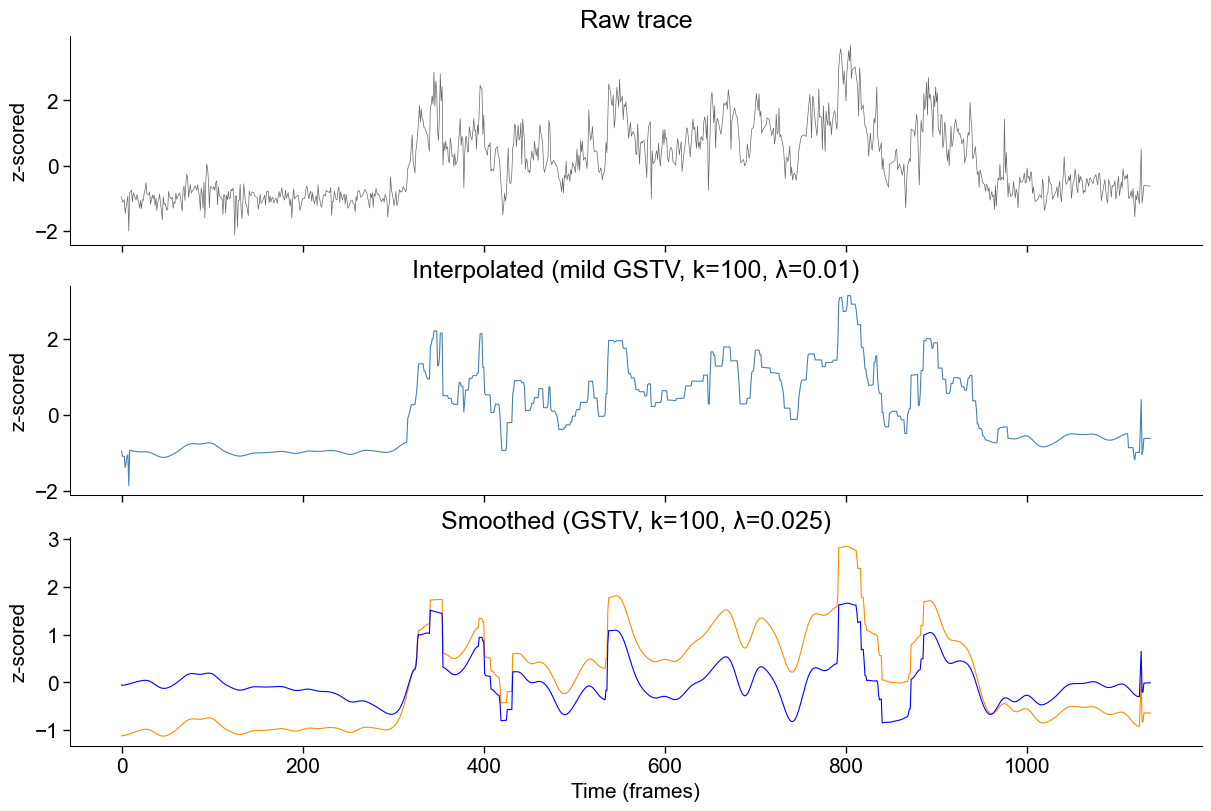

In [207]:
# --- Apply smooth_neural_data to the NSM trace ---
%matplotlib inline
plt.close('all')
nsm_idx = data['gcamp']['idx_nsm']

# Build a (n_timepoints, 1) array so smooth_neural_data can iterate over neurons
if hasattr(nsm_idx, '__len__') and len(nsm_idx) > 1:
    raw = data['gcamp']['trace_array'][:, nsm_idx[0] - 1][:, None]
else:
    raw = data['gcamp']['trace_array'][:, int(nsm_idx) - 1][:, None]

smooth_traces, interp_traces = smooth_neural_data_gstv(raw, k=100, lam=0.025, fluc_thresh_std=3)

filtered_data = highpass_filter_data(smooth_traces.T).T

# Plot raw vs smoothed
fig, axes, nt = utils.pretty_subplots(nrows=3, ncols=1, figsize=(12, 8), sharex=True)

ax0 = nt()
ax0.plot(raw[:, 0], 'k', lw=0.5, alpha=0.6, label='raw')
ax0.set_ylabel('z-scored')
ax0.set_title('Raw trace')

ax1 = nt()
ax1.plot(interp_traces[:, 0], 'steelblue', lw=0.8, label='interpolated (mild TV)')
ax1.set_ylabel('z-scored')
ax1.set_title('Interpolated (mild GSTV, k=100, λ=0.01)')

ax2 = nt()
ax2.plot(smooth_traces[:, 0], 'darkorange', lw=0.8, label='smooth (k=100, λ=0.025)')
ax2.plot(filtered_data[:, 0], 'blue', lw=0.8, label='highpass filtered')
ax2.set_ylabel('z-scored')
ax2.set_xlabel('Time (frames)')
ax2.set_title('Smoothed (GSTV, k=100, λ=0.025)')

plt.show()


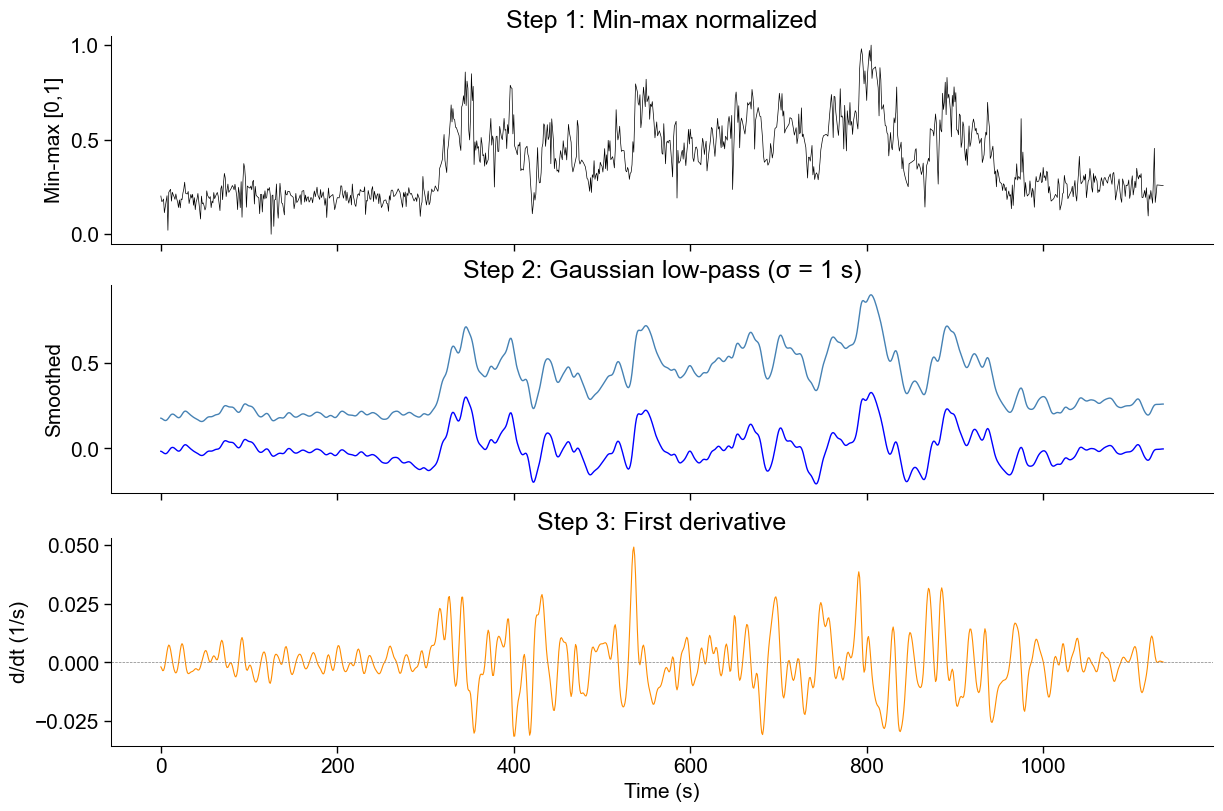

In [209]:
# --- Apply normalize → Gaussian smooth → derivative pipeline ---

# Use the F/F20 trace for the spontaneous activity analysis
nsm_idx = data['gcamp']['idx_nsm']
if hasattr(nsm_idx, '__len__') and len(nsm_idx) > 1:
    nsm_trace = data['gcamp']['traces_array_F_F20'][:, nsm_idx[0] - 1]
else:
    nsm_trace = data['gcamp']['traces_array_F_F20'][:, int(nsm_idx) - 1]

# dt from volume_rate
volume_rate = data['timing'].get('volume_rate', 1.0)
if isinstance(volume_rate, np.ndarray):
    volume_rate = volume_rate.item()
dt = 1.0 / volume_rate

normalized, smoothed, derivative = normalize_smooth_derivative(nsm_trace, dt, sigma_seconds=3.0)
smoothed_filtered = highpass_filter_data(smoothed, order=1, critical_freq=0.005, do_plot=False)

time_axis = np.arange(len(nsm_trace)) * dt

fig, axes, nt = utils.pretty_subplots(nrows=3, ncols=1, figsize=(12, 8), sharex=True)

ax0 = nt()
ax0.plot(time_axis, normalized, 'k', lw=0.5)
ax0.set_ylabel('Min-max [0,1]')
ax0.set_title('Step 1: Min-max normalized')

ax1 = nt()
ax1.plot(time_axis, smoothed, 'steelblue', lw=1)
ax1.plot(time_axis,smoothed_filtered, 'blue', lw=1, label='highpass filtered')
ax1.set_ylabel('Smoothed')
ax1.set_title('Step 2: Gaussian low-pass (σ = 1 s)')

ax2 = nt()
ax2.plot(time_axis, derivative, 'darkorange', lw=0.8)
ax2.axhline(0, color='grey', lw=0.5, ls='--')
ax2.set_ylabel('d/dt (1/s)')
ax2.set_xlabel('Time (s)')
ax2.set_title('Step 3: First derivative')

plt.show()


# perform frequency analysis on all data

In [53]:
# Choose which trace to analyze
trace_key = 'trace_array'   # F/F20 trace
nsm_idx = data['gcamp']['idx_nsm']

# Handle single vs multiple NSM indices
if hasattr(nsm_idx, '__len__') and len(nsm_idx) > 1:
    nsm_trace = data['gcamp'][trace_key][:, nsm_idx[0] - 1]
else:
    nsm_trace = data['gcamp'][trace_key][:, int(nsm_idx) - 1]

Processing swf415_no_id dataset...
  Loading C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf415_no_id\2022-01-16-01-data.h5...
  neuron 1/1


C:\Users\munib\AppData\Local\Temp\ipykernel_25236\4063495989.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  nsm_trace = data['gcamp'][trace_key][:, int(nsm_idx) - 1]


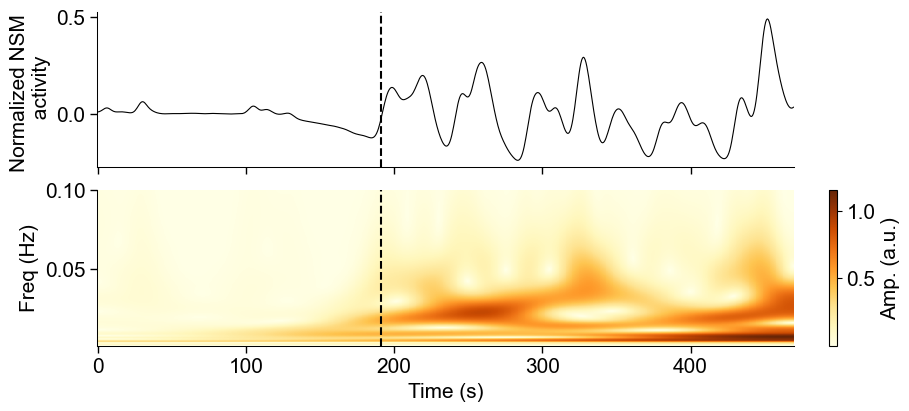

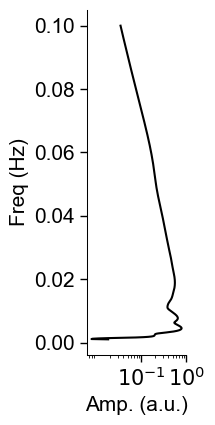

  Loading C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf415_no_id\2022-01-25-01-data.h5...
  neuron 1/1


C:\Users\munib\AppData\Local\Temp\ipykernel_25236\4063495989.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  nsm_trace = data['gcamp'][trace_key][:, int(nsm_idx) - 1]


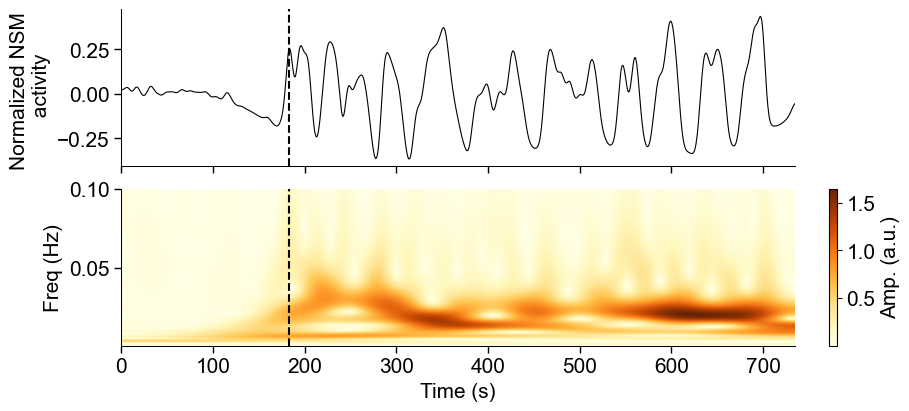

c:\Users\munib\POSTDOC\CODE\Dag_Nwabudike_Kang_2025\utils.py:80: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


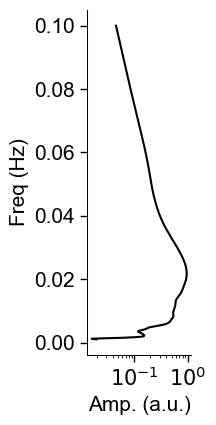

  Loading C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf415_no_id\2022-03-17-01-data.h5...
  neuron 1/1


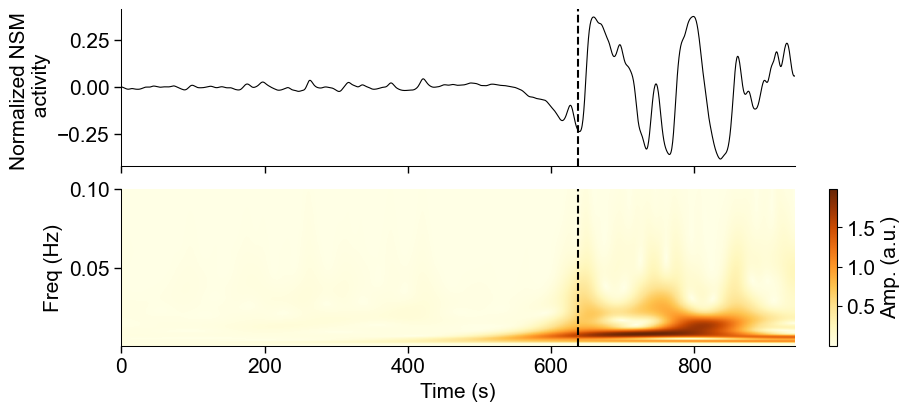

c:\Users\munib\POSTDOC\CODE\Dag_Nwabudike_Kang_2025\utils.py:80: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


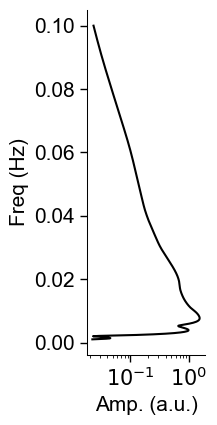

  Loading C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf415_no_id\2022-03-25-03-data.h5...
  neuron 1/1


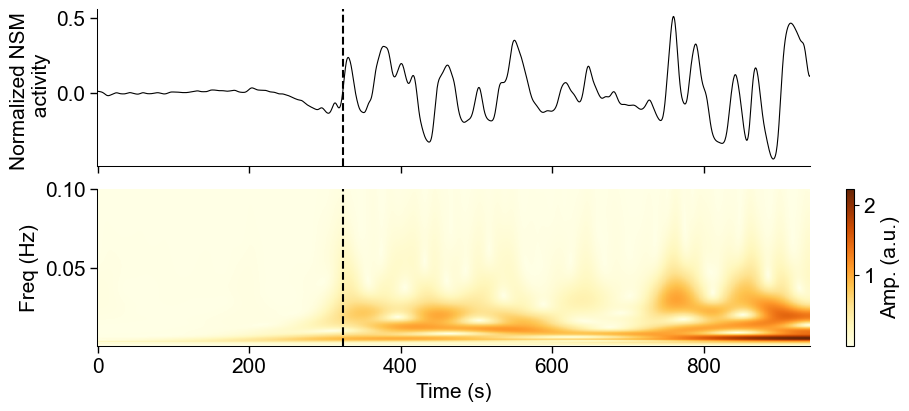

c:\Users\munib\POSTDOC\CODE\Dag_Nwabudike_Kang_2025\utils.py:80: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


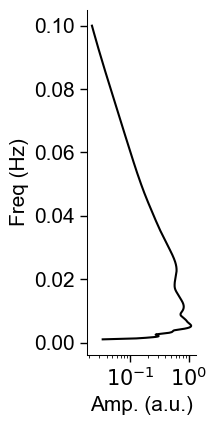

  Loading C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf415_no_id\2022-04-05-01-data.h5...
  neuron 1/1


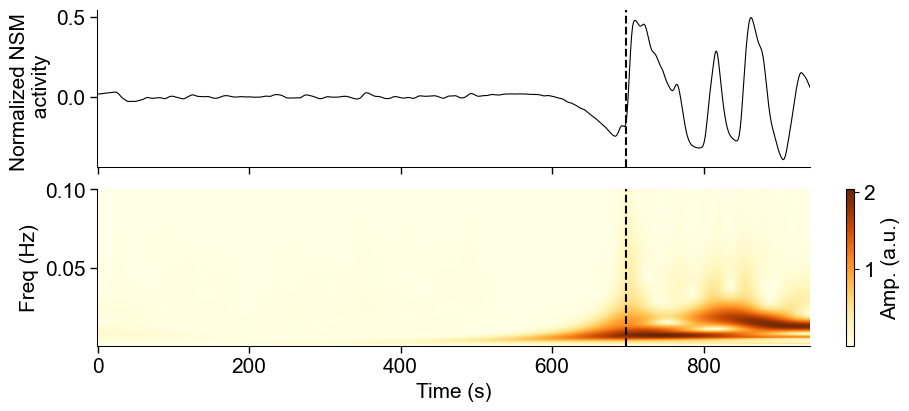

c:\Users\munib\POSTDOC\CODE\Dag_Nwabudike_Kang_2025\utils.py:80: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


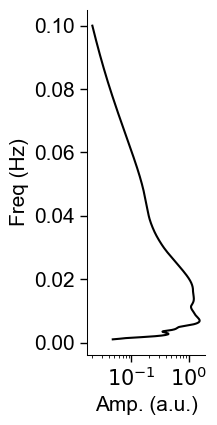

  Loading C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf415_no_id\2022-04-12-02-data.h5...
  neuron 1/1


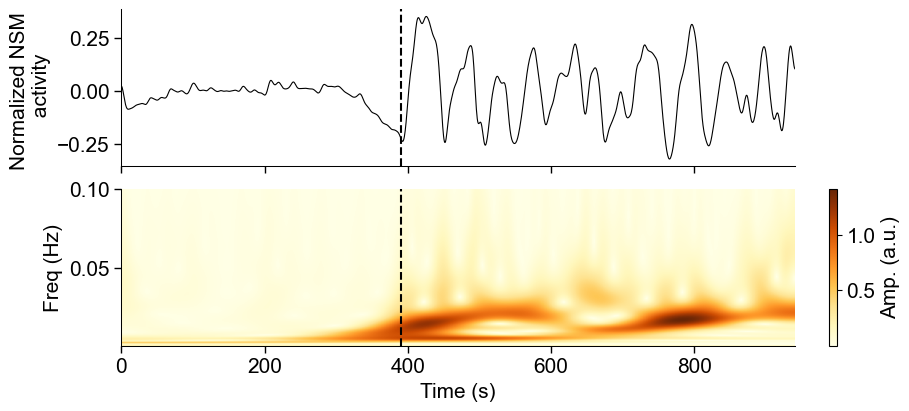

c:\Users\munib\POSTDOC\CODE\Dag_Nwabudike_Kang_2025\utils.py:80: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


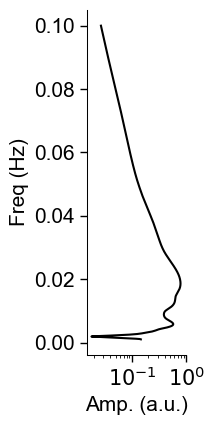

  Loading C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf415_no_id\2022-05-02-01-data.h5...
  neuron 1/1


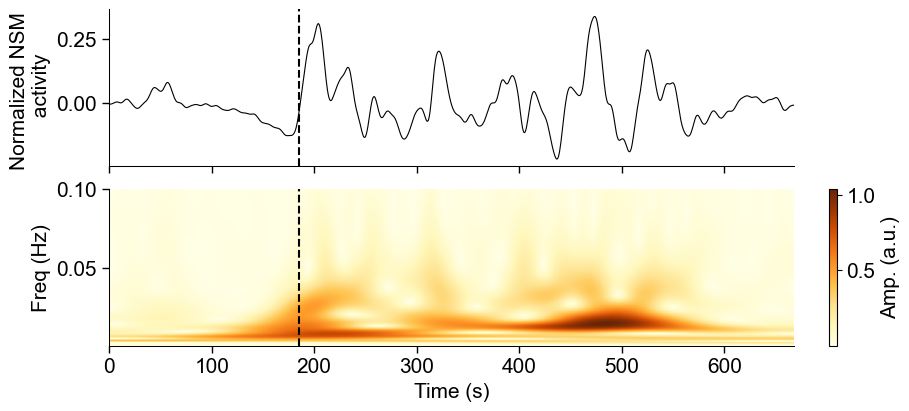

c:\Users\munib\POSTDOC\CODE\Dag_Nwabudike_Kang_2025\utils.py:80: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


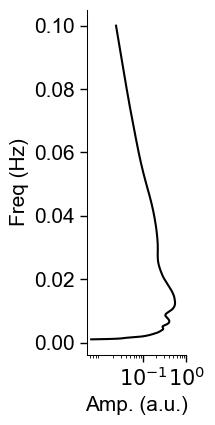

In [227]:
# Choose which trace to analyze

%matplotlib inline


data_pth = r'C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024'

trace_key = 'trace_array'   # F/F20 trace

swf_pth = ['swf415_no_id']

# Frequencies to analyse (paper: 0.01 – 0.2 Hz)
freqs = np.linspace(0.001, 0.1, 1000)

plt.close('all')

for swf in swf_pth:
    print(f'Processing {swf} dataset...')
    swf_dir = os.path.join(data_pth, swf)
    h5_files = glob.glob(os.path.join(swf_dir, '*.h5'))

    amp_recordings = np.full((len(h5_files), freqs.shape[0]), np.nan)

    for i,h5_file in enumerate(h5_files):
        print(f'  Loading {h5_file}...')
        with h5py.File(h5_file, 'r') as h5f:
            data = utils.h5_to_dict(h5f)


        nsm_idx = data['gcamp']['idx_nsm']

        # Handle single vs multiple NSM indices
        if hasattr(nsm_idx, '__len__') and len(nsm_idx) > 1: # average of NSM pairs if there are multiple NSM indices
            nsm_trace = np.mean(np.concatenate((data['gcamp'][trace_key][:, nsm_idx[0] - 1].reshape(-1,1), data['gcamp'][trace_key][:, nsm_idx[1] - 1].reshape(-1,1)), axis=1), axis=1)
        else:
            nsm_trace = data['gcamp'][trace_key][:, int(nsm_idx) - 1]

        # normalize nsm_trace b/w 0 and 1
        nsm_trace = minmax_normalize(nsm_trace)

        # gstv denoise nsm_trace
        nsm_trace_smoothed, _ = smooth_neural_data_gstv(nsm_trace.reshape(1, -1).T)

        nsm_trace_filtered = highpass_filter_data(nsm_trace_smoothed.T).T


        # Sampling interval (seconds per frame) — adjust if your data has a different frame rate
        volume_rate = 1.7
        if isinstance(volume_rate, np.ndarray):
            volume_rate = volume_rate.item()
        dt = 1.0 / volume_rate  # seconds per frame

        normalized, smoothed, derivative = normalize_smooth_derivative(nsm_trace, dt, sigma_seconds=3.0)
        smoothed_filtered = highpass_filter_data(smoothed, order=2, critical_freq=0.005, do_plot=False)

        # Compute wavelet spectrum
        W = wavelet_spectrum(smoothed_filtered, freqs, dt, ksi=4.0)

        # ---- Plot the wavelet amplitude spectrogram ----
        fig, axes, nt = utils.pretty_subplots(nrows=2, ncols=1, figsize=(9, 4), sharex=True)

        time_axis = np.arange(len(nsm_trace)) * dt  # seconds

        ax0 = nt()
        ax0.plot(time_axis, smoothed_filtered, 'k', linewidth=0.8)
        ax0.axvline(data['timing']['time_food_encounter'] * dt, color='black', ls='--', label='food encounter')
        ax0.set_ylabel('Normalized NSM \n activity')
        # ax0.legend(loc='upper right')

        ax1 = nt()
        im = ax1.pcolormesh(time_axis, freqs, np.abs(W).T, shading='auto', cmap='YlOrBr')
        ax1.axvline(data['timing']['time_food_encounter'] * dt, color='black', ls='--')
        ax1.set_ylabel('Freq (Hz)')
        ax1.set_xlabel('Time (s)')
        fig.colorbar(im, ax=ax1, label='Amp. (a.u.)')
        # plt.tight_layout()
        plt.show()

        # --- Time-averaged wavelet spectrum ---

        # Average from onset of spontaneous activity (food encounter) to end of recording
        food_idx = int(data['timing']['time_food_encounter'])
        avg_spectrum = time_averaged_spectrum(W, start_idx=food_idx, end_idx=None)

        # plot the time-averaged spectrum on logx scale
        fig, ax = utils.pretty_plot(figsize=(2.4, 4.5))
        ax.plot(avg_spectrum, freqs, 'k', linewidth=1.5)
        ax.set_xscale('log')
        ax.set_xlabel('Amp. (a.u.)')
        ax.set_ylabel('Freq (Hz)')
        ax.set_xticks([10**-1, 10**0])
        ax.set_xticklabels([r'$10^{-1}$', r'$10^{0}$'])
        # ax.set_title('Time-averaged wavelet spectrum')
        plt.tight_layout()
        plt.show()

        # collect average spectrum from each recording's NSM
        amp_recordings[i,:] = avg_spectrum





In [214]:
# frequency with highest amplitude in each recording
peak_freqs = freqs[np.argmax(amp_recordings, axis=1)]
print('Peak frequencies across recordings:', peak_freqs)

Peak frequencies across recordings: [0.005 0.022 0.008 0.005 0.007 0.019 0.013]


c:\Users\munib\POSTDOC\CODE\Dag_Nwabudike_Kang_2025\utils.py:80: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


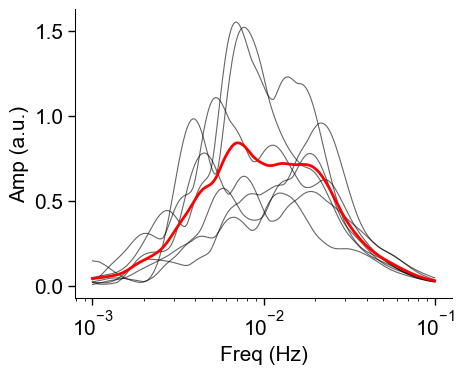

In [228]:
# plot all recordings' average spectra together
fig, ax = utils.pretty_plot(figsize=(5,4))
for i in range(amp_recordings.shape[0]):
    # ax.plot(amp_recordings[i,:], freqs, 'k', lw=0.8, alpha=0.6)
    ax.plot(freqs, amp_recordings[i,:], 'k', lw=0.8, alpha=0.6)
ax.plot(freqs, np.nanmean(amp_recordings, axis=0), 'red', lw=2, label='mean')
ax.set_xscale('log')
ax.set_xlabel('Freq (Hz)')
ax.set_ylabel('Amp (a.u.)')
# ax.set_xticks([10**-1, 10**0])
# ax.set_xticklabels([r'$10^{-1}$', r'$10^{0}$'])
plt.tight_layout()
plt.show()


# perform frequency analysis on g5ht ROI data

In [247]:
import pandas as pd

# PTH = r'C:\Users\munib\POSTDOC\DATA\g5ht-free\20251028\date-20251028_time-1500_strain-ISg5HT_condition-starvedpatch_worm001'
PTH = r'D:\DATA\g5ht-free\20260123\date-20260123_strain-ISg5HT-nsIS180_condition-fedpatch_worm004'

baseline_window = (0,50) # frames
encounter_frame = 167
encounter_sec = encounter_frame * 0.533 
encounter_min = encounter_sec / 60
normalize_to_max = False

good_frames = (250, 1200) # frames to include in analysis

# Predefined hex colors for each ROI label (consistent across datasets)
LABEL_COLORS = {
    # long-form labels
    'procorpus':          '#F94144',
    'metacorpus':         '#FF9129',
    'isthmus':            '#F3BD3E',
    'terminal_bulb':      '#FFD981',
    'nerve_ring':         '#90BE6D',
    'ventral_nerve_cord': '#43AA8B',
    'dorsal_nerve_cord':  '#000000',
    # short-form labels
    'PC':                 '#F94144',
    'MC':                 '#FF9129',
    'IM':                 '#F3BD3E',
    'TB':                 '#FFD981',
    'NR':                 '#90BE6D',
    'VNC':                '#43AA8B',
    'DNC':                '#000000',
    # old labels (if any)
    'NR':                '#90BE6D',
}

_FALLBACK_COLORS = ['#17becf', '#bcbd22', '#7f7f7f', '#aec7e8', '#ffbb78', '#98df8a']


def get_label_color(label, fallback_idx=0):
    """Return the hex color for a given label, with fallback for unknown labels."""
    if label in LABEL_COLORS:
        return LABEL_COLORS[label]
    return _FALLBACK_COLORS[fallback_idx % len(_FALLBACK_COLORS)]


df = pd.read_csv(os.path.join(PTH, 'quantified.csv'), index_col=0)
t = df.index.values
if 'dorsal_nerve_cord' in df.columns:
    df = df.drop(columns=['dorsal_nerve_cord'])
if 'DNC' in df.columns:
    df = df.drop(columns=['DNC'])


# get data as numpy array
out = df.values
# get column labels
labels = df.columns.tolist()
nlabels = out.shape[1]

# sort labels, and corresponding data and colors, by label name
sorted_indices = np.argsort(labels)
labels = [labels[i] for i in sorted_indices]
out = out[:, sorted_indices]


# get good frames only
t = t[good_frames[0]:good_frames[1]]
out = out[good_frames[0]:good_frames[1], :]

c:\Users\munib\POSTDOC\CODE\Dag_Nwabudike_Kang_2025\utils.py:80: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


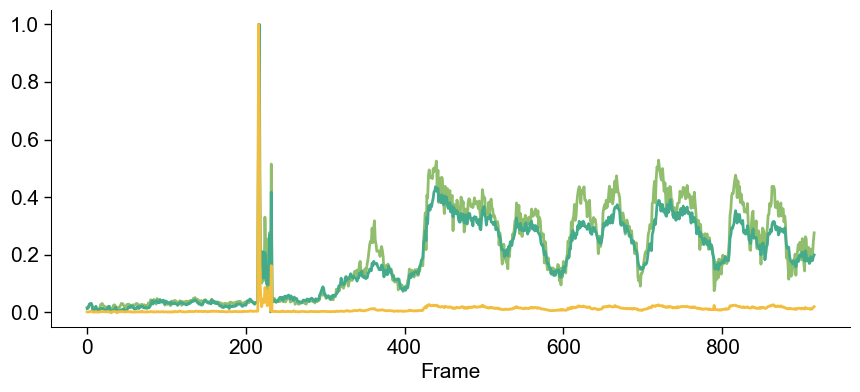

In [250]:
%matplotlib inline
fig, ax = utils.pretty_plot(figsize=(9,4))

fallback_idx = 0
for i in range(nlabels):
    c = get_label_color(labels[i], fallback_idx)
    if labels[i] not in LABEL_COLORS:
        fallback_idx += 1
    r_baseline = np.mean(out[baseline_window[0]:baseline_window[1], i])
    r_over_baseline = out[:, i] / r_baseline

    # normalize b/w 0 and 1
    normalized = minmax_normalize(r_over_baseline)

    # gstv denoise 
    # smoothed, _ = smooth_neural_data_gstv(normalized.reshape(1, -1).T)
    smoothed = normalized

    t = smoothed.shape[0]

    # ax.plot(np.arange(t) * 0.533, smoothed, label=labels[i], color=c, lw=2)
    ax.plot(np.arange(t), smoothed, label=labels[i], color=c, lw=2)


plt.xlabel('Frame')
plt.show()

  neuron 1/1


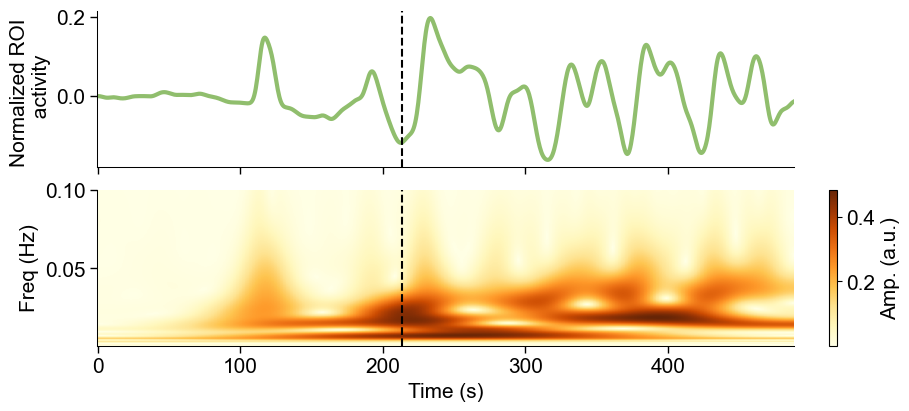

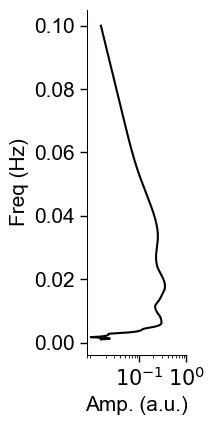

  neuron 1/1


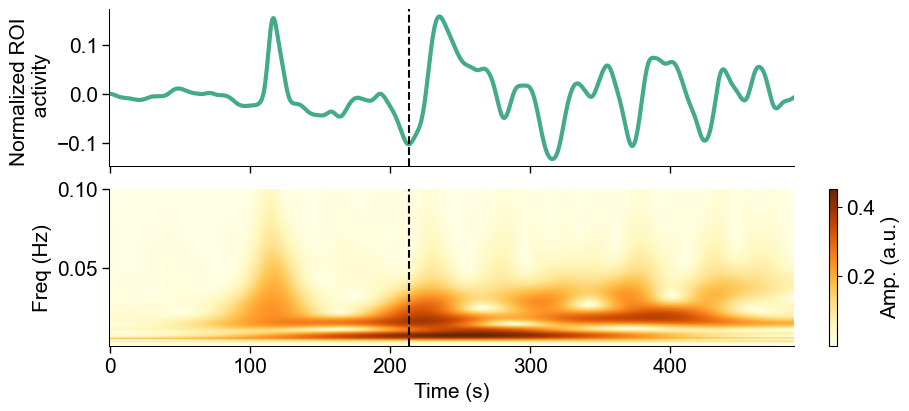

c:\Users\munib\POSTDOC\CODE\Dag_Nwabudike_Kang_2025\utils.py:80: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


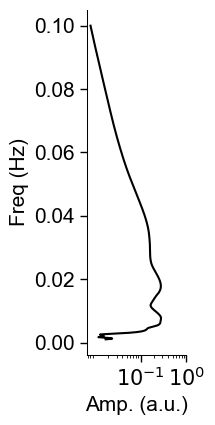

  neuron 1/1


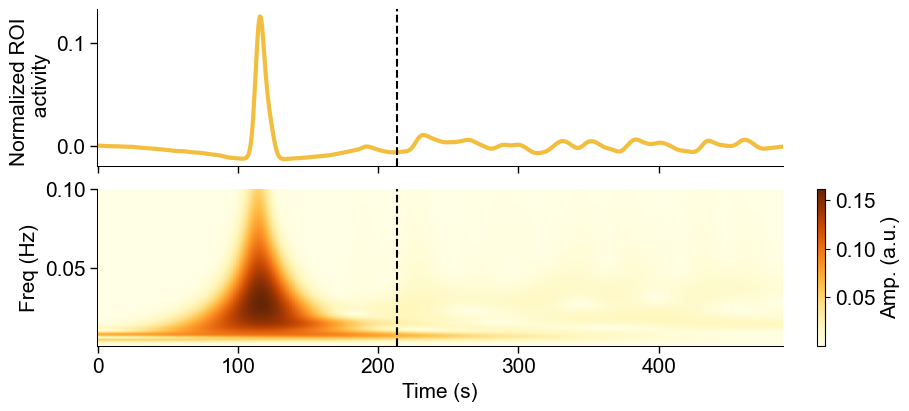

c:\Users\munib\POSTDOC\CODE\Dag_Nwabudike_Kang_2025\utils.py:80: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


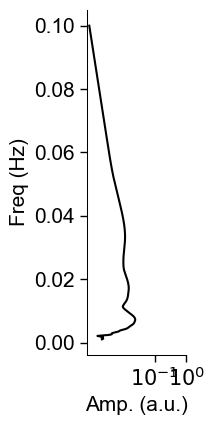

In [245]:
%matplotlib inline

freqs = np.linspace(0.001, 0.1, 1000)

plt.close('all')

food_idx = 400

all_roi_avg_spectrum = np.full((nlabels, freqs.shape[0]), np.nan)

fallback_idx = 0
for i in range(nlabels):
    c = get_label_color(labels[i], fallback_idx)
    if labels[i] not in LABEL_COLORS:
        fallback_idx += 1
    r_baseline = np.mean(out[baseline_window[0]:baseline_window[1], i])
    r_over_baseline = out[:, i] / r_baseline

    # normalize b/w 0 and 1
    normalized = minmax_normalize(r_over_baseline)

    # gstv denoise 
    smoothed, _ = smooth_neural_data_gstv(normalized.reshape(1, -1).T)

    # Sampling interval (seconds per frame) — adjust if your data has a different frame rate
    volume_rate = 1/(0.533)
    if isinstance(volume_rate, np.ndarray):
        volume_rate = volume_rate.item()
    dt = 1.0 / volume_rate  # seconds per frame

    normalized, smoothed, derivative = normalize_smooth_derivative(r_over_baseline, dt, sigma_seconds=3.0)
    smoothed_filtered = highpass_filter_data(smoothed, order=2, critical_freq=0.005, do_plot=False)

    # Compute wavelet spectrum
    W = wavelet_spectrum(smoothed_filtered, freqs, dt, ksi=4.0)

    # ---- Plot the wavelet amplitude spectrogram ----
    fig, axes, nt = utils.pretty_subplots(nrows=2, ncols=1, figsize=(9, 4), sharex=True)

    time_axis = np.arange(len(r_over_baseline)) * dt  # seconds

    ax0 = nt()
    ax0.plot(time_axis, smoothed_filtered, c=c, linewidth=3)
    ax0.axvline(food_idx * dt, color='black', ls='--', label='food encounter')
    ax0.set_ylabel('Normalized ROI \n activity')
    # ax0.legend(loc='upper right')

    ax1 = nt()
    im = ax1.pcolormesh(time_axis, freqs, np.abs(W).T, shading='auto', cmap='YlOrBr')
    ax1.axvline(food_idx * dt, color='black', ls='--')
    ax1.set_ylabel('Freq (Hz)')
    ax1.set_xlabel('Time (s)')
    fig.colorbar(im, ax=ax1, label='Amp. (a.u.)')
    # plt.tight_layout()
    plt.show()

    # --- Time-averaged wavelet spectrum ---

    # Average from onset of spontaneous activity (food encounter) to end of recording
    avg_spectrum = time_averaged_spectrum(W, start_idx=food_idx, end_idx=None)

    # plot the time-averaged spectrum on logx scale
    fig, ax = utils.pretty_plot(figsize=(2.4, 4.5))
    ax.plot(avg_spectrum, freqs, 'k', linewidth=1.5)
    ax.set_xscale('log')
    ax.set_xlabel('Amp. (a.u.)')
    ax.set_ylabel('Freq (Hz)')
    ax.set_xticks([10**-1, 10**0])
    ax.set_xticklabels([r'$10^{-1}$', r'$10^{0}$'])
    # ax.set_title('Time-averaged wavelet spectrum')
    plt.tight_layout()
    plt.show()

    # collect average spectrum from each ROI
    all_roi_avg_spectrum[i,:] = avg_spectrum

c:\Users\munib\POSTDOC\CODE\Dag_Nwabudike_Kang_2025\utils.py:80: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


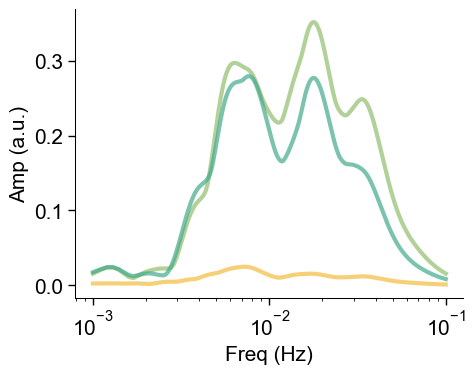

In [246]:
%matplotlib inline

# plot all ROIs average spectra together
fig, ax = utils.pretty_plot(figsize=(5,4))
fallback_idx = 0
for i in range(nlabels):
    c = get_label_color(labels[i], fallback_idx)
    if labels[i] not in LABEL_COLORS:
        fallback_idx += 1
    ax.plot(freqs,all_roi_avg_spectrum[i,:], c=c, lw=3, alpha=0.7)
ax.set_xscale('log')
ax.set_xlabel('Freq (Hz)')
ax.set_ylabel('Amp (a.u.)')
# ax.set_xticks([10**-1, 10**0])
# ax.set_xticklabels([r'$10^{-1}$', r'$10^{0}$'])
plt.tight_layout()
plt.show()
